In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Dataset

I used the **daily** *System Price of Electricity* dataset published by the ONS and based on Elexon BMRS data. It covers **January 2020 to March 2026** and includes the daily average price and a 7-day rolling average for Great Britain.

In [18]:
DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")

df = pd.read_excel(DATA_RAW/"electricity_prices_dataset_ONS.xlsx", sheet_name="1.Daily SP Electricity", header = 4)
df.head(10)

,Date,Daily average,Seven-day rolling average
0,2020-01-01,3.951209,3.721139
1,2020-01-02,1.771417,3.486188
2,2020-01-03,2.135458,3.112760
3,2020-01-04,2.699667,2.988641
4,2020-01-05,2.758000,2.853293
5,2020-01-06,3.471598,2.944565
6,2020-01-07,2.875125,2.808925
7,2020-01-08,3.053792,2.680722
8,2020-01-09,3.061168,2.864972
9,2020-01-10,4.486438,3.200827


In [14]:
df.columns

Index(['Date', 'Daily average', 'Seven-day rolling average'], dtype='str')

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2280 entries, 0 to 2279
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       2280 non-null   datetime64[us]
 1   Daily average              2280 non-null   float64       
 2   Seven-day rolling average  2280 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 53.6 KB


In [22]:
df.columns = ['date', 'daily_avg', '7d_rolling_avg']
df.head()

,date,daily_avg,7d_rolling_avg
0,2020-01-01,3.951209,3.721139
1,2020-01-02,1.771417,3.486188
2,2020-01-03,2.135458,3.112760
3,2020-01-04,2.699667,2.988641
4,2020-01-05,2.758000,2.853293


In [27]:
df["date"].min(), df["date"].max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2026-03-29 00:00:00'))

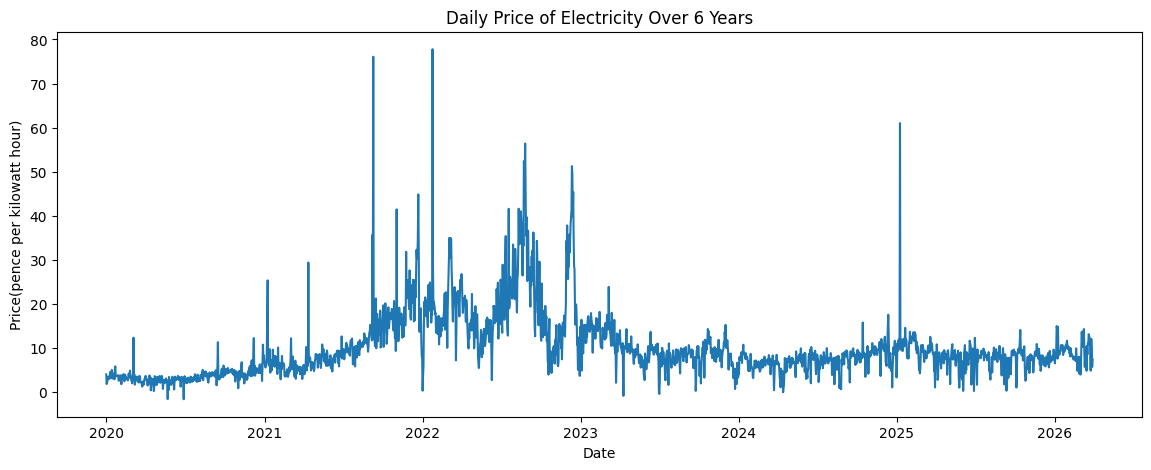

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df["date"], df["daily_avg"])
plt.title("Daily Price of Electricity Over 6 Years")
plt.xlabel("Date")
plt.ylabel("Price(pence per kilowatt hour)")
plt.show()

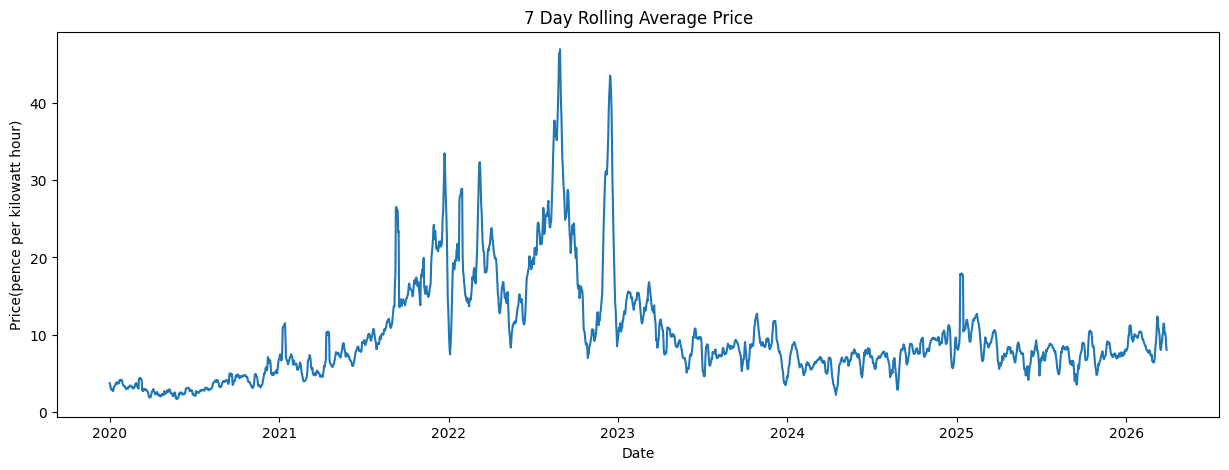

In [34]:
plt.figure(figsize=(15,5))
plt.title("7 Day Rolling Average Price")
plt.plot(df["date"], df["7d_rolling_avg"])
plt.xlabel("Date")
plt.ylabel("Price(pence per kilowatt hour)")
plt.show()

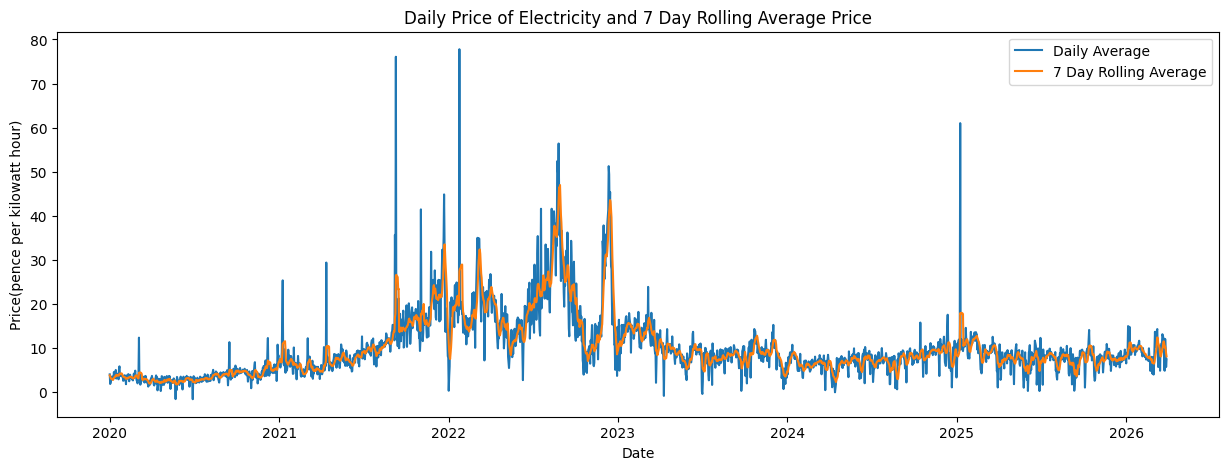

In [43]:
plt.figure(figsize=(15,5))
plt.plot(df["date"],df["daily_avg"], label="Daily Average")
plt.plot(df["date"],df["7d_rolling_avg"], label="7 Day Rolling Average")
plt.title("Daily Price of Electricity and 7 Day Rolling Average Price")
plt.xlabel("Date")
plt.ylabel("Price(pence per kilowatt hour)")
plt.legend()
plt.show()

## Notes on the chart

This chart shows the daily electricity price over time, along with a 7-day rolling average.

A few simple things stand out:

- In the earlier years, prices are generally lower and more stable.
- From late 2021 into 2022, prices become much more volatile and there are several very large spikes.
- After that period, prices come down again, but the market still shows some sudden jumps.
- The 7-day rolling average helps show the overall trend more clearly by smoothing out daily noise.

This suggests that electricity prices do not behave in a completely stable way over time. Some periods are relatively calm, while others are much more unpredictable. That matters for forecasting, because a model that works reasonably well in stable periods may struggle during sharp market shocks.

This is also broadly in line with what I expected to see. Energy prices are influenced by real-world events, and the large increase in volatility around 2021–2022 fits with the wider energy crisis and the disruption that followed the war in Ukraine. In general, electricity prices can also be affected by other external pressures, such as geopolitical tensions, supply problems, inflation, and changes in market demand. For the same reason, I would also expect some pressure on prices in 2026 given the renewed conflict in the Middle East, although that effect is not as pronounced in this chart as the earlier energy crisis period.

In [46]:
df[["daily_avg","7d_rolling_avg"]].describe()

,daily_avg,7d_rolling_avg
count,2280.000000,2280.000000
mean,9.865304,9.859951
std,7.421379,6.681594
min,-1.691145,1.644460
25%,5.409318,6.004351
50%,8.264948,8.034649
75%,11.475538,11.253226
max,77.790390,46.946877


I was interested to see that electricity prices can briefly become negative. This usually happens when supply is very high and demand is low, so excess power in the market pushes prices below zero for a short time.

In [47]:
df.nlargest(10,"daily_avg")

,date,daily_avg,7d_rolling_avg
754,2022-01-24,77.790390,27.350632
617,2021-09-09,76.077979,26.417717
1834,2025-01-08,61.002188,17.859348
968,2022-08-26,56.378111,43.778390
965,2022-08-23,52.365394,36.787891
1076,2022-12-12,51.235494,38.900537
966,2022-08-24,50.735587,38.457523
1077,2022-12-13,49.342313,40.847823
967,2022-08-25,49.222268,40.460725
1079,2022-12-15,45.362397,43.533639


In [48]:
df.nsmallest(10,"daily_avg")

,date,daily_avg,7d_rolling_avg
179,2020-06-28,-1.691145,2.242983
142,2020-05-22,-1.663004,1.891385
1195,2023-04-10,-0.933706,7.759869
1278,2023-07-02,-0.489956,6.086362
1564,2024-04-13,-0.112427,2.748476
1277,2023-07-01,0.088366,7.685920
2005,2025-06-28,0.169168,4.705500
110,2020-04-20,0.172391,2.011185
1980,2025-06-03,0.185160,4.933632
1362,2023-09-24,0.209916,5.919915
